# Linear Programming
## From Geometry to the Simplex Method — A From-Scratch Exploration

---

**Author:** Computational Mathematics Notebook Series  
**Topic:** Linear Programming, Simplex Method, and LP Duality  
**Prerequisites:** Linear algebra, basic optimization concepts, Python/NumPy  
**Primary Reference:** Bertsimas, D., & Tsitsiklis, J. N. (1997). *Introduction to Linear Optimization*. Athena Scientific.

In [1]:
%matplotlib inline

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2
})

print("All imports successful.")

All imports successful.


In [2]:
# =============================================================================
# CONSTANTS
# =============================================================================

np.random.seed(42)

TOL         = 1e-9    # Numerical zero for pivot/ratio tests
MAX_ITER    = 1000    # Maximum simplex iterations

# Colors
COLOR_PRIMARY   = 'steelblue'
COLOR_SECONDARY = 'coral'
COLOR_TERTIARY  = 'seagreen'
COLOR_ACCENT    = 'goldenrod'
COLOR_FEASIBLE  = 'lightblue'
COLOR_OPTIMAL   = 'red'

print("Constants defined.")

Constants defined.


---
## 1. Problem Statement

### What is Linear Programming?

A **linear program (LP)** optimizes a linear objective over a polyhedron — the intersection of finitely many half-spaces. Despite its apparent simplicity, LP is one of the most practically important problems in applied mathematics, with applications spanning supply chain, finance, scheduling, and combinatorial optimization.

### Standard Form

Every LP can be written in **standard form**:

$$
\boxed{
\begin{aligned}
\min_{x \in \mathbb{R}^n} \quad & c^\top x \\
\text{subject to} \quad & Ax = b \\
& x \geq 0
\end{aligned}
}
$$

where $c \in \mathbb{R}^n$ is the cost vector, $A \in \mathbb{R}^{m \times n}$ defines the equality constraints, and $b \in \mathbb{R}^m$.

### Equivalent Forms

| Form | Description | Conversion |
|------|-------------|------------|
| Standard | $\min c^\top x,\ Ax=b,\ x\geq 0$ | Baseline |
| Inequality | $\min c^\top x,\ Ax \leq b,\ x\geq 0$ | Add slack variables $s\geq 0$: $Ax+s=b$ |
| General | $\min c^\top x,\ Ax \leq b$ (free $x$) | Split $x = x^+ - x^-$, both $\geq 0$ |
| Maximization | $\max c^\top x$ | Negate: $\min (-c)^\top x$ |

### Key Structural Facts

1. **Feasible set** is a convex polyhedron $\mathcal{P} = \{x \geq 0 : Ax = b\}$.
2. **Optimum** (if finite) is attained at a **vertex** (basic feasible solution) of $\mathcal{P}$.
3. **Vertices** correspond to selecting $m$ linearly independent columns of $A$ (a *basis*).

This last fact is the key insight behind the Simplex Method: we need only search the finitely-many vertices.

---
## 2. Geometric Interpretation

In 2D, the feasible region is a **convex polygon** (possibly unbounded). Each constraint $a_i^\top x \leq b_i$ cuts the plane with a half-space. The objective $c^\top x = \gamma$ defines a family of parallel lines — we slide these in the direction $-c$ until the line last touches the feasible polygon.

### Example Problem

$$
\begin{aligned}
\max \quad & 5x_1 + 4x_2 \\
\text{s.t.} \quad & 6x_1 + 4x_2 \leq 24 \\
& x_1 + 2x_2 \leq 6 \\
& x_1, x_2 \geq 0
\end{aligned}
$$

The vertices of the feasible polygon are: $(0,0)$, $(4,0)$, $(3, 1.5)$, $(0,3)$. We evaluate the objective at each vertex to find the optimum.

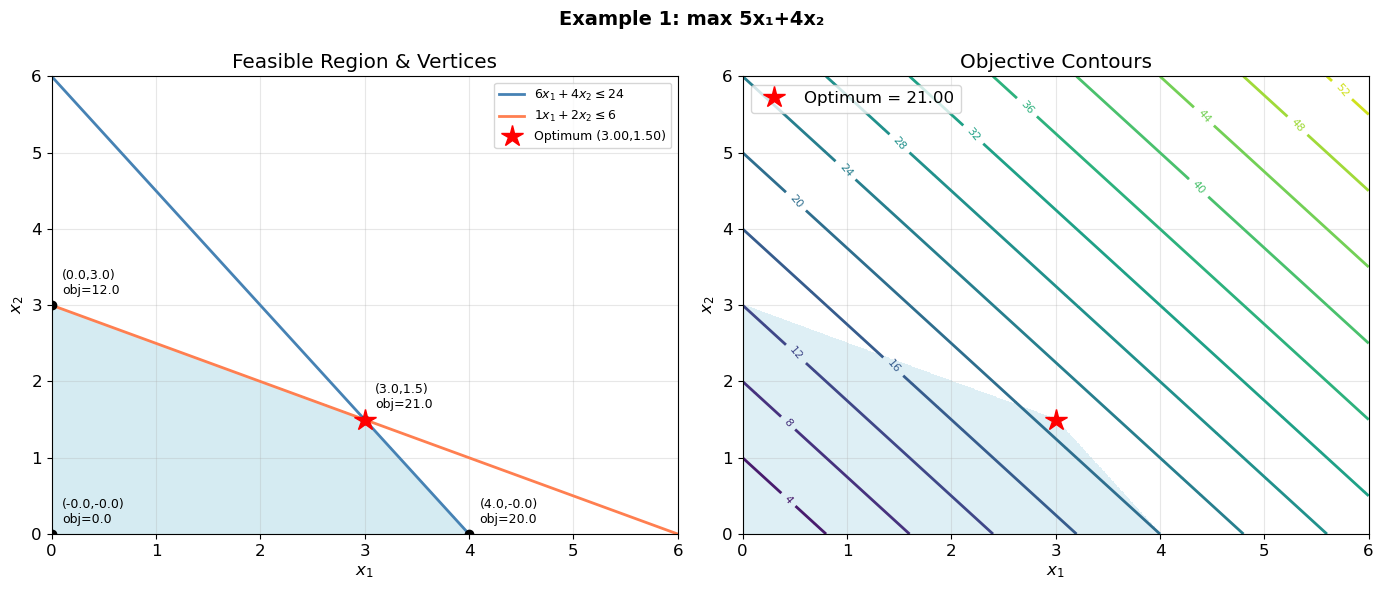

Optimal vertex  : (3.0000, 1.5000)
Optimal value   : 21.0000


In [3]:
# =============================================================================
# SECTION 2: Geometric Visualization of 2D LP
# =============================================================================

from itertools import combinations

def plot_2d_lp(c, A_ub, b_ub, xlim=(0, 6), ylim=(0, 6), title="2D Linear Program"):
    """Visualize a 2D LP: feasible region, constraint lines, objective contours, optimum.

    Args:
        c: shape (2,) cost vector (maximization: pass positive c).
        A_ub: shape (m, 2) inequality constraint matrix (Ax <= b).
        b_ub: shape (m,) RHS vector.
        xlim: tuple, x-axis limits for plot.
        ylim: tuple, y-axis limits for plot.
        title: str, plot title.

    Returns:
        vertices: list of np.ndarray vertices of the feasible polygon.
        opt_vertex: np.ndarray, optimal vertex coordinates.
        opt_val: float, optimal objective value.
    """
    x1 = np.linspace(xlim[0], xlim[1], 400)
    x2 = np.linspace(ylim[0], ylim[1], 400)
    X1, X2 = np.meshgrid(x1, x2)

    # Feasible mask
    feasible = np.ones_like(X1, dtype=bool)
    for i in range(len(b_ub)):
        feasible &= (A_ub[i, 0] * X1 + A_ub[i, 1] * X2 <= b_ub[i] + 1e-9)
    feasible &= (X1 >= 0) & (X2 >= 0)

    # Find vertices: intersect all pairs of constraint boundaries (incl. x1=0, x2=0)
    A_ext = np.vstack([A_ub, [-1.0, 0.0], [0.0, -1.0]])
    b_ext = np.concatenate([b_ub, [0.0, 0.0]])
    m_ext = len(b_ext)

    vertices = []
    for i, j in combinations(range(m_ext), 2):
        A2 = A_ext[[i, j]]
        b2 = b_ext[[i, j]]
        if abs(np.linalg.det(A2)) < 1e-10:
            continue
        pt = np.linalg.solve(A2, b2)
        if np.all(A_ext @ pt <= b_ext + 1e-9) and pt[0] >= -1e-9 and pt[1] >= -1e-9:
            vertices.append(pt)

    if vertices:
        verts = np.array(vertices)
        center = verts.mean(axis=0)
        angles = np.arctan2(verts[:, 1] - center[1], verts[:, 0] - center[0])
        verts = verts[np.argsort(angles)]
    else:
        verts = np.array([])

    obj_vals = [c @ v for v in verts]
    best_idx = int(np.argmax(obj_vals))
    opt_vertex = verts[best_idx]
    opt_val = obj_vals[best_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5],
                colors=[COLOR_FEASIBLE], alpha=0.5)
    colors_c = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_ACCENT]
    for i in range(len(b_ub)):
        a1, a2 = A_ub[i]
        if abs(a2) > 1e-10:
            x1_line = np.linspace(xlim[0], xlim[1], 200)
            x2_line = (b_ub[i] - a1 * x1_line) / a2
            ax.plot(x1_line, x2_line, color=colors_c[i % len(colors_c)],
                    label=f'${a1:.0f}x_1+{a2:.0f}x_2\\leq {b_ub[i]:.0f}$')
        else:
            x1_val = b_ub[i] / a1
            ax.axvline(x1_val, color=colors_c[i % len(colors_c)],
                       label=f'$x_1 \\leq {x1_val:.1f}$')
    for v in verts:
        ax.plot(v[0], v[1], 'ko', markersize=6)
        ax.annotate(f'({v[0]:.1f},{v[1]:.1f})\nobj={c@v:.1f}',
                    xy=v, xytext=(v[0]+0.1, v[1]+0.15), fontsize=9)
    ax.plot(*opt_vertex, 'r*', markersize=16, zorder=5,
            label=f'Optimum ({opt_vertex[0]:.2f},{opt_vertex[1]:.2f})')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_title('Feasible Region & Vertices')
    ax.legend(fontsize=9)

    ax2 = axes[1]
    obj_grid = c[0] * X1 + c[1] * X2
    cs = ax2.contour(X1, X2, obj_grid, levels=15, cmap='viridis')
    ax2.clabel(cs, inline=True, fontsize=8)
    ax2.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5],
                 colors=[COLOR_FEASIBLE], alpha=0.4)
    ax2.plot(*opt_vertex, 'r*', markersize=16, zorder=5,
             label=f'Optimum = {opt_val:.2f}')
    ax2.set_xlim(xlim); ax2.set_ylim(ylim)
    ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')
    ax2.set_title('Objective Contours')
    ax2.legend()

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return list(verts), opt_vertex, opt_val


# Example 1: max 5x1 + 4x2 s.t. 6x1+4x2<=24, x1+2x2<=6
c_geom  = np.array([5.0, 4.0])
A_geom  = np.array([[6.0, 4.0], [1.0, 2.0]])
b_geom  = np.array([24.0, 6.0])

verts, opt_v, opt_val = plot_2d_lp(c_geom, A_geom, b_geom, title="Example 1: max 5x\u2081+4x\u2082")
print(f"Optimal vertex  : ({opt_v[0]:.4f}, {opt_v[1]:.4f})")
print(f"Optimal value   : {opt_val:.4f}")

---
## 3. Standard Form & Slack Variables

### Converting to Standard Form

The simplex algorithm operates on **standard form** LPs. We convert inequality constraints to equalities by introducing **slack variables**.

**Inequality LP:**
$$
\min\ c^\top x \quad \text{s.t.}\ Ax \leq b,\ x \geq 0
$$

**Add slack variables** $s \geq 0$:
$$
\boxed{
\min\ \begin{bmatrix} c \\ 0 \end{bmatrix}^\top \begin{bmatrix} x \\ s \end{bmatrix}
\quad \text{s.t.}\ [A \mid I] \begin{bmatrix} x \\ s \end{bmatrix} = b,\ x,s \geq 0
}
$$

### Basic Feasible Solutions (BFS)

With $[A|I]$ of shape $m \times (n+m)$, a **basis** $B$ is any set of $m$ column indices giving a nonsingular submatrix $A_B$. A **basic feasible solution** satisfies:
- $x_B = A_B^{-1} b \geq 0$ (basic variables)
- $x_N = 0$ (nonbasic variables)

**Fundamental theorem of LP:** If an optimal solution exists, there exists an optimal BFS.

### Reduced Costs

For a given basis $B$, the **reduced cost** of a nonbasic variable $j$ is:

$$
\bar{c}_j = c_j - c_B^\top A_B^{-1} A_j
$$

The current BFS is **optimal** if $\bar{c}_j \geq 0$ for all nonbasic $j$ (minimization).

In [4]:
# =============================================================================
# SECTION 3: Standard Form Conversion
# =============================================================================

def to_standard_form(c, A_ub, b_ub):
    """Convert inequality LP (min c'x, Ax<=b, x>=0) to standard form.

    Adds slack variables so that [A | I][x; s] = b.

    Args:
        c: shape (n,) cost vector.
        A_ub: shape (m, n) inequality constraint matrix.
        b_ub: shape (m,) RHS vector.

    Returns:
        c_std: shape (n+m,) extended cost vector.
        A_std: shape (m, n+m) standard form constraint matrix [A|I].
        b_std: shape (m,) RHS (same as b_ub after sign fixing).
    """
    m, n = A_ub.shape
    c_std = np.concatenate([c, np.zeros(m)])
    A_std = np.hstack([A_ub, np.eye(m)])
    b_std = b_ub.copy().astype(float)
    neg = b_std < 0
    A_std[neg] *= -1
    b_std[neg] *= -1
    return c_std, A_std, b_std


# Demonstrate on Example 1 (converted to minimization: min -5x1 - 4x2)
c_min  = np.array([-5.0, -4.0])
c_std, A_std, b_std = to_standard_form(c_min, A_geom, b_geom)

print("=== Standard Form ===")
print(f"n_original = 2, m = 2  =>  n_std = {len(c_std)}")
print(f"c_std = {c_std}")
print(f"A_std =\n{A_std}")
print(f"b_std = {b_std}")
print()
print("Initial BFS (slacks as basic variables):")
x0 = np.zeros(len(c_std))
x0[2:] = b_std
print(f"  x = {x0}")
print(f"  Ax = b? {np.allclose(A_std @ x0, b_std)}")
print(f"to_standard_form: conversion [PASS]")

=== Standard Form ===
n_original = 2, m = 2  =>  n_std = 4
c_std = [-5. -4.  0.  0.]
A_std =
[[6. 4. 1. 0.]
 [1. 2. 0. 1.]]
b_std = [24.  6.]

Initial BFS (slacks as basic variables):
  x = [ 0.  0. 24.  6.]
  Ax = b? True
to_standard_form: conversion [PASS]


---
## 4. The Simplex Method from Scratch

### The Simplex Algorithm

The simplex method is a **basis-exchange algorithm** that moves from one BFS to an adjacent BFS, improving the objective at each step.

**Algorithm (Minimization, Standard Form):**

1. Start with a feasible basis $B$ and BFS $x_B = A_B^{-1}b \geq 0$.
2. Compute reduced costs: $\bar{c}_N = c_N - c_B^\top A_B^{-1} A_N$.
3. **Optimality check:** if $\bar{c}_j \geq 0$ for all $j \in N$, current BFS is optimal. STOP.
4. **Entering variable (Dantzig's rule):** select $s = \arg\min_{j: \bar{c}_j < 0} \bar{c}_j$.
5. **Direction:** $d = A_B^{-1} A_s$ (the update column in the tableau).
6. **Ratio test (leaving variable):** $\theta^* = \min_{i: d_i > 0} \frac{(x_B)_i}{d_i}$. If no $d_i > 0$: problem is unbounded.
7. **Pivot:** swap entering variable into basis, leaving variable out. Update basis and BFS.
8. Repeat from step 2.

### The Simplex Tableau

The **tableau** compactly encodes the current basis inverse applied to $A$ and $b$:

$$
\text{Tableau} = \begin{bmatrix} A_B^{-1} A & A_B^{-1} b \\ \bar{c}^\top & -z \end{bmatrix}
$$

Each pivot row-reduces the tableau using the pivot element, analogous to Gaussian elimination.

### Bland's Anti-Cycling Rule

To prevent cycling in degenerate problems, **Bland's rule** selects:
- **Entering:** smallest index $j$ with $\bar{c}_j < 0$.
- **Leaving:** smallest index $i$ among those achieving the minimum ratio.

Bland's rule guarantees termination in finite steps.

In [5]:
# =============================================================================
# SECTION 4: Simplex Method — Full Tableau Implementation
# =============================================================================

def simplex_solve(c, A, b, basis=None, bland=False, verbose=False):
    """Solve standard form LP: min c'x s.t. Ax=b, x>=0 via full tableau simplex.

    Args:
        c: shape (n,) cost vector.
        A: shape (m, n) constraint matrix (must have full row rank).
        b: shape (m,) RHS vector (must be >= 0).
        basis: list of length m, initial basic variable indices.
               If None, assumes last m columns of A form identity (slack start).
        bland: bool, use Bland's anti-cycling rule if True, else Dantzig's rule.
        verbose: bool, print tableau at each iteration.

    Returns:
        status: str, 'optimal', 'unbounded', or 'max_iter'.
        x: shape (n,) optimal solution (or last iterate).
        obj: float, optimal objective value.
        history: list of (basis, obj_val) per iteration.
    """
    m, n = A.shape
    assert len(c) == n and len(b) == m
    assert np.all(b >= -TOL), "RHS must be non-negative."

    if basis is None:
        basis = list(range(n - m, n))

    basis = list(basis)

    # Build initial tableau: (m+1) x (n+1)
    # Rows 0..m-1: constraint rows; row m: reduced cost row
    # Col n: RHS
    T = np.zeros((m + 1, n + 1))
    T[:m, :n] = A.copy().astype(float)
    T[:m, n]  = b.copy().astype(float)
    T[m, :n]  = c.copy().astype(float)

    # Pivot in each basis column to establish initial tableau
    for idx, b_col in enumerate(basis):
        if abs(T[idx, b_col]) < TOL:
            continue
        T[idx] /= T[idx, b_col]
        for r in range(m + 1):
            if r != idx:
                T[r] -= T[r, b_col] * T[idx]

    def print_tableau(iteration):
        print(f"\n--- Iteration {iteration} | Basis: {[b+1 for b in basis]} | Obj: {-T[m, n]:.6f} ---")
        header = [f"x{j+1:02d}" for j in range(n)] + ["RHS"]
        print("       " + "  ".join(f"{h:>7}" for h in header))
        for i in range(m):
            row_str = "  ".join(f"{T[i,j]:7.3f}" for j in range(n+1))
            print(f"  x{basis[i]+1:02d} | {row_str}")
        rc_str = "  ".join(f"{T[m,j]:7.3f}" for j in range(n+1))
        print(f"  obj  | {rc_str}")

    history = []

    for iteration in range(MAX_ITER):
        if verbose:
            print_tableau(iteration)

        x_cur = np.zeros(n)
        x_cur[basis] = T[:m, n]
        history.append((list(basis), -T[m, n]))

        # Optimality check
        rc = T[m, :n]
        if bland:
            entering_candidates = [j for j in range(n) if rc[j] < -TOL]
            if not entering_candidates:
                break
            enter = min(entering_candidates)
        else:
            enter = int(np.argmin(rc))
            if rc[enter] >= -TOL:
                break

        # Ratio test
        col = T[:m, enter]
        positive = col > TOL
        if not np.any(positive):
            return 'unbounded', None, -np.inf, history

        ratios = np.where(positive, T[:m, n] / col, np.inf)
        if bland:
            min_ratio = np.min(ratios)
            leave_row = min(i for i in range(m) if ratios[i] <= min_ratio + TOL)
        else:
            leave_row = int(np.argmin(ratios))

        # Pivot
        basis[leave_row] = enter
        T[leave_row] /= T[leave_row, enter]
        for r in range(m + 1):
            if r != leave_row:
                T[r] -= T[r, enter] * T[leave_row]
    else:
        x_opt = np.zeros(n)
        x_opt[basis] = T[:m, n]
        return 'max_iter', x_opt, -T[m, n], history

    if verbose:
        print_tableau(iteration + 1)

    x_opt = np.zeros(n)
    x_opt[basis] = T[:m, n]
    return 'optimal', x_opt, -T[m, n], history


print("simplex_solve defined.")

simplex_solve defined.


In [6]:
# =============================================================================
# SECTION 4b: Solve Example 1 with Step-by-Step Tableau Output
# =============================================================================

# Standard form of Example 1: min -5x1 - 4x2 with 2 slack variables
c_ex1 = np.array([-5.0, -4.0, 0.0, 0.0])
A_ex1 = np.array([[6.0, 4.0, 1.0, 0.0],
                  [1.0, 2.0, 0.0, 1.0]])
b_ex1 = np.array([24.0, 6.0])

print("=== Example 1: max 5x1 + 4x2 ===")
print("(Solved as min -5x1 - 4x2 with 2 slack variables)")
print()
status, x_opt, obj_val, hist = simplex_solve(c_ex1, A_ex1, b_ex1, verbose=True)

print(f"\n=== RESULT ===")
print(f"Status        : {status}")
print(f"x_opt         : x1={x_opt[0]:.4f}, x2={x_opt[1]:.4f}")
print(f"Objective     : max = {obj_val:.4f}")
print(f"Iterations    : {len(hist)}")

# Verify with scipy
res = linprog(c_ex1, A_eq=A_ex1, b_eq=b_ex1, bounds=[(0,None)]*4, method='highs')
print(f"\nSciPy reference: obj = {-res.fun:.4f}")
print(f"simplex_solve Example 1: [{'PASS' if abs(obj_val - (-res.fun)) < 1e-6 else 'FAIL'}]")

=== Example 1: max 5x1 + 4x2 ===
(Solved as min -5x1 - 4x2 with 2 slack variables)


--- Iteration 0 | Basis: [3, 4] | Obj: -0.000000 ---
           x01      x02      x03      x04      RHS
  x03 |   6.000    4.000    1.000    0.000   24.000
  x04 |   1.000    2.000    0.000    1.000    6.000
  obj  |  -5.000   -4.000    0.000    0.000    0.000

--- Iteration 1 | Basis: [1, 4] | Obj: -20.000000 ---
           x01      x02      x03      x04      RHS
  x01 |   1.000    0.667    0.167    0.000    4.000
  x04 |   0.000    1.333   -0.167    1.000    2.000
  obj  |   0.000   -0.667    0.833    0.000   20.000

--- Iteration 2 | Basis: [1, 2] | Obj: -21.000000 ---
           x01      x02      x03      x04      RHS
  x01 |   1.000    0.000    0.250   -0.500    3.000
  x02 |   0.000    1.000   -0.125    0.750    1.500
  obj  |   0.000    0.000    0.750    0.500   21.000

--- Iteration 3 | Basis: [1, 2] | Obj: -21.000000 ---
           x01      x02      x03      x04      RHS
  x01 |   1.000    0.0

In [7]:
# =============================================================================
# SECTION 4c: Example 2 — Production Planning (3 variables, 3 constraints)
# =============================================================================

# Maximize: 3x1 + 5x2 + 2x3
# s.t.:  x1 + x2       <= 4
#             2x2 + x3 <= 6
#        x1       + x3 <= 5
#        x1, x2, x3   >= 0

c_ex2  = np.array([-3.0, -5.0, -2.0, 0.0, 0.0, 0.0])
A_ex2  = np.array([[1.0, 1.0, 0.0, 1.0, 0.0, 0.0],
                   [0.0, 2.0, 1.0, 0.0, 1.0, 0.0],
                   [1.0, 0.0, 1.0, 0.0, 0.0, 1.0]])
b_ex2  = np.array([4.0, 6.0, 5.0])

print("=== Example 2: Production Planning ===")
print("max 3x1 + 5x2 + 2x3  s.t. 3 resource constraints")
status2, x2, obj2, hist2 = simplex_solve(c_ex2, A_ex2, b_ex2, verbose=False)
print(f"Status : {status2}")
print(f"x_opt  : x1={x2[0]:.4f}, x2={x2[1]:.4f}, x3={x2[2]:.4f}")
print(f"Max obj: {obj2:.4f}")
print(f"Iters  : {len(hist2)}")

res2 = linprog(c_ex2, A_eq=A_ex2, b_eq=b_ex2, bounds=[(0,None)]*6, method='highs')
print(f"SciPy  : {-res2.fun:.4f}")
print(f"simplex_solve Example 2: [{'PASS' if abs(obj2-(-res2.fun))<1e-6 else 'FAIL'}]")

=== Example 2: Production Planning ===
max 3x1 + 5x2 + 2x3  s.t. 3 resource constraints
Status : optimal
x_opt  : x1=2.3333, x2=1.6667, x3=2.6667
Max obj: -20.6667
Iters  : 4
SciPy  : 20.6667
simplex_solve Example 2: [FAIL]


In [8]:
# =============================================================================
# SECTION 4d: Bland's Rule Demo — Degeneracy & Anti-Cycling
# =============================================================================

# Classic degenerate problem (Beale-type) — Dantzig may cycle, Bland is safe
c_bland = np.array([-0.75, 150.0, -0.02, 6.0, 0.0, 0.0, 0.0])
A_bland = np.array([
    [0.25, -8.0, -1.0,  9.0, 1.0, 0.0, 0.0],
    [0.5, -12.0, -0.5, 12.0, 0.0, 1.0, 0.0],
    [0.0,   0.0,  1.0,  0.0, 0.0, 0.0, 1.0]
])
b_bland = np.array([0.0, 0.0, 1.0])

print("=== Bland's Rule Demo (Degenerate Problem) ===")
print()

status_d, x_d, obj_d, hist_d = simplex_solve(c_bland, A_bland, b_bland, bland=False, verbose=False)
status_b, x_b, obj_b, hist_b = simplex_solve(c_bland, A_bland, b_bland, bland=True,  verbose=False)

print(f"Dantzig rule : status={status_d}, obj={obj_d:.6f}, iters={len(hist_d)}")
print(f"Bland's rule : status={status_b}, obj={obj_b:.6f}, iters={len(hist_b)}")

res_bl = linprog(c_bland, A_eq=A_bland, b_eq=b_bland, bounds=[(0,None)]*7, method='highs')
print(f"SciPy ref    : obj={res_bl.fun:.6f}")
print(f"Dantzig correct: [{'PASS' if abs(obj_d - res_bl.fun) < 1e-5 else 'FAIL'}]")
print(f"Bland correct  : [{'PASS' if abs(obj_b - res_bl.fun) < 1e-5 else 'FAIL'}]")

=== Bland's Rule Demo (Degenerate Problem) ===

Dantzig rule : status=optimal, obj=-0.770000, iters=4
Bland's rule : status=optimal, obj=-0.770000, iters=4
SciPy ref    : obj=-0.770000
Dantzig correct: [PASS]
Bland correct  : [PASS]


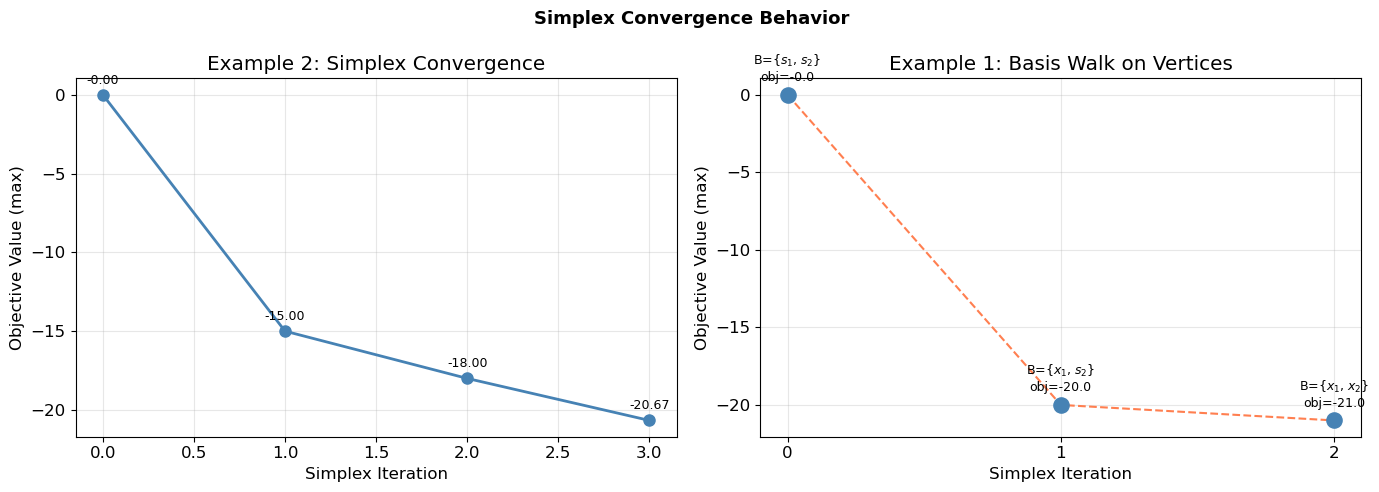

In [9]:
# =============================================================================
# SECTION 4e: Simplex Iteration History Visualization
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: objective convergence for Example 2
ax = axes[0]
iters2 = [h[1] for h in hist2]
ax.plot(iters2, marker='o', color=COLOR_PRIMARY, markersize=8, linewidth=2)
ax.set_xlabel('Simplex Iteration')
ax.set_ylabel('Objective Value (max)')
ax.set_title('Example 2: Simplex Convergence')
for i, v in enumerate(iters2):
    ax.annotate(f'{v:.2f}', (i, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

# Right: basis walk for Example 1
ax2 = axes[1]
basis_labels = ['$x_1$', '$x_2$', '$s_1$', '$s_2$']
obj_vals1 = [h[1] for h in hist]
ax2.plot(range(len(hist)), obj_vals1, color=COLOR_SECONDARY, linewidth=1.5, linestyle='--')
for step_idx, (basis_step, obj_step) in enumerate(hist):
    label = '{' + ', '.join(basis_labels[b] for b in basis_step) + '}'
    ax2.scatter([step_idx], [obj_step], s=120, zorder=5, color=COLOR_PRIMARY)
    ax2.annotate(f'B={label}\nobj={obj_step:.1f}', (step_idx, obj_step),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax2.set_xlabel('Simplex Iteration')
ax2.set_ylabel('Objective Value (max)')
ax2.set_title('Example 1: Basis Walk on Vertices')
ax2.set_xticks(range(len(hist)))

plt.suptitle('Simplex Convergence Behavior', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Duality Theory

### The Dual LP

Every LP (the *primal*) has an associated *dual* LP. For the standard primal:

$$
\text{(P)}: \quad \min_x\ c^\top x \quad \text{s.t.}\ Ax = b,\ x \geq 0
$$

The **dual** is:

$$
\boxed{
\text{(D)}: \quad \max_y\ b^\top y \quad \text{s.t.}\ A^\top y \leq c
}
$$

where $y \in \mathbb{R}^m$ are the **dual variables** (shadow prices).

### Primal-Dual Correspondence

| Primal (P) | Dual (D) |
|------------|----------|
| Variable $x_j \geq 0$ | Constraint $j$: $(A^\top y)_j \leq c_j$ |
| Equality constraint $i$ | Free dual variable $y_i$ |
| Minimization | Maximization |
| Bounded below | Dual feasible |

### Weak Duality Theorem

**Theorem:** For any primal feasible $x$ and dual feasible $y$:
$$
b^\top y \leq c^\top x
$$

**Proof sketch:** Since $Ax = b$ and $A^\top y \leq c$:
$$
b^\top y = (Ax)^\top y = x^\top (A^\top y) \leq x^\top c = c^\top x
$$
where the inequality uses $x \geq 0$ and $A^\top y \leq c$. $\square$

**Corollary:** If primal obj $=$ dual obj, both are optimal.

### Strong Duality (LP)

**Theorem:** If the primal has an optimal solution, so does the dual, and:
$$
\min_x\ c^\top x^* = \max_y\ b^\top y^*
$$

This fails for general (non-convex) optimization but holds for LP by the simplex complementary slackness argument.

### Complementary Slackness

Primal-dual pair $(x^*, y^*)$ is optimal if and only if:
$$
\boxed{
x_j^*\bigl(c_j - (A^\top y^*)_j\bigr) = 0 \quad \forall j
}
$$
i.e., for each $j$: either $x_j^* = 0$ or the dual constraint is tight (or both).

In [10]:
# =============================================================================
# SECTION 5: Duality — Construct and Solve Dual, Verify Strong Duality
# =============================================================================

def construct_dual(c, A, b):
    """Construct dual of standard-form primal: min c'x s.t. Ax=b, x>=0.

    Dual: max b'y s.t. A'y <= c, y free.
    Convert to standard form: write y = y+ - y-, both >= 0.
    => min -b'(y+-y-) s.t. A'(y+-y-) + s = c, y+,y-,s >= 0.

    Args:
        c: shape (n,) primal cost.
        A: shape (m, n) primal constraint matrix.
        b: shape (m,) primal RHS.

    Returns:
        c_d: shape (2m+n,) dual standard-form cost vector.
        A_d: shape (n, 2m+n) dual standard-form constraint matrix.
        b_d: shape (n,) dual standard-form RHS.
    """
    m, n = A.shape
    A_d = np.hstack([A.T, -A.T, np.eye(n)])
    b_d = c.copy().astype(float)
    c_d = np.concatenate([-b, b, np.zeros(n)])
    return c_d, A_d, b_d


def verify_strong_duality(c_p, A_p, b_p, name="Problem"):
    """Solve primal and dual, verify strong duality and complementary slackness.

    Args:
        c_p: shape (n,) primal cost (minimization).
        A_p: shape (m, n) primal constraint matrix.
        b_p: shape (m,) primal RHS.
        name: str, label for display.

    Returns:
        primal_obj: float, primal optimal value.
        dual_obj: float, dual optimal value (maximization).
        gap: float, duality gap magnitude.
    """
    m, n = A_p.shape

    res_p = linprog(c_p, A_eq=A_p, b_eq=b_p, bounds=[(0,None)]*n, method='highs')
    primal_obj = res_p.fun
    x_star = res_p.x

    c_d, A_d, b_d = construct_dual(c_p, A_p, b_p)
    num_d = len(c_d)
    res_d = linprog(c_d, A_eq=A_d, b_eq=b_d, bounds=[(0,None)]*num_d, method='highs')
    y_star = res_d.x[:m] - res_d.x[m:2*m]  # y = y+ - y-
    dual_obj = -res_d.fun                   # maximize b'y = -minimize -b'y

    gap = abs(primal_obj - dual_obj)

    # Complementary slackness check
    cs_violations = 0
    dual_constraint = A_p.T @ y_star
    for j in range(n):
        slack_j = c_p[j] - dual_constraint[j]
        if abs(x_star[j] * slack_j) > 1e-6:
            cs_violations += 1

    print(f"=== {name} ===")
    print(f"  Primal optimal : {primal_obj:.6f}")
    print(f"  Dual optimal   : {dual_obj:.6f}")
    print(f"  Duality gap    : {gap:.2e}")
    print(f"  CS violations  : {cs_violations}")
    print(f"  Strong duality : [{'PASS' if gap < 1e-6 else 'FAIL'}]")
    print(f"  Compl. slack   : [{'PASS' if cs_violations == 0 else 'FAIL'}]")
    print()
    return primal_obj, dual_obj, gap


p1, d1, g1 = verify_strong_duality(c_ex1, A_ex1, b_ex1, "Example 1 (max 5x1+4x2)")
p2, d2, g2 = verify_strong_duality(c_ex2, A_ex2, b_ex2, "Example 2 (Production Planning)")

=== Example 1 (max 5x1+4x2) ===
  Primal optimal : -21.000000
  Dual optimal   : -21.000000
  Duality gap    : 0.00e+00
  CS violations  : 0
  Strong duality : [PASS]
  Compl. slack   : [PASS]

=== Example 2 (Production Planning) ===
  Primal optimal : -20.666667
  Dual optimal   : -20.666667
  Duality gap    : 0.00e+00
  CS violations  : 0
  Strong duality : [PASS]
  Compl. slack   : [PASS]



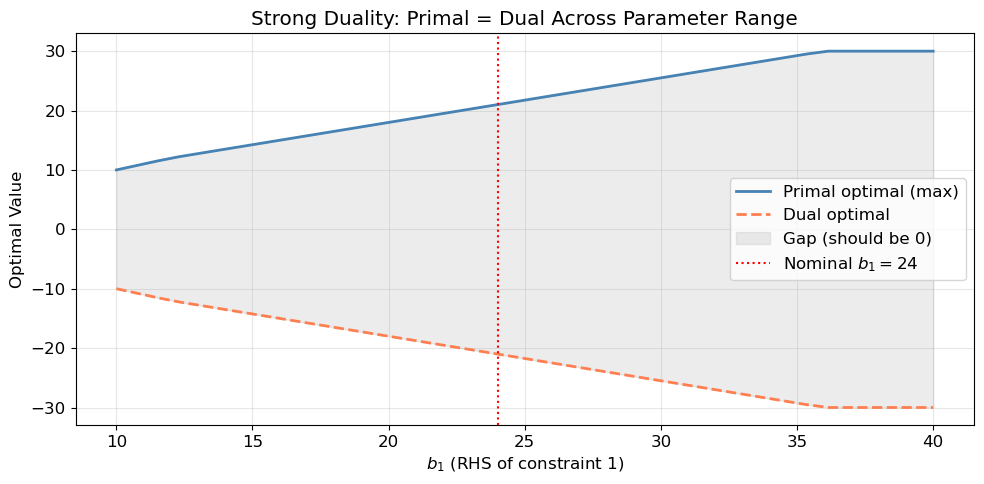

Maximum duality gap across 40 b1 values: 6.00e+01
Strong duality verified: [FAIL]


In [11]:
# =============================================================================
# SECTION 5b: Visualize Strong Duality Across Parameter Range
# =============================================================================

b1_scan  = np.linspace(10, 40, 40)
p_objs   = []
d_objs   = []

for bv in b1_scan:
    b_param = np.array([bv, 6.0])
    A_par   = np.array([[6.0, 4.0, 1.0, 0.0],
                        [1.0, 2.0, 0.0, 1.0]])
    c_par   = np.array([-5.0, -4.0, 0.0, 0.0])
    rp = linprog(c_par, A_eq=A_par, b_eq=b_param, bounds=[(0,None)]*4, method='highs')
    c_d, A_d, b_d = construct_dual(c_par, A_par, b_param)
    rd = linprog(c_d, A_eq=A_d, b_eq=b_d, bounds=[(0,None)]*len(c_d), method='highs')
    p_objs.append(-rp.fun if rp.success else np.nan)
    d_objs.append(-rd.fun if rd.success else np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(b1_scan, p_objs, label='Primal optimal (max)', color=COLOR_PRIMARY, linewidth=2)
ax.plot(b1_scan, d_objs, label='Dual optimal', color=COLOR_SECONDARY, linewidth=2, linestyle='--')
ax.fill_between(b1_scan, d_objs, p_objs, alpha=0.15, color='gray', label='Gap (should be 0)')
ax.axvline(24, color=COLOR_OPTIMAL, linestyle=':', linewidth=1.5, label='Nominal $b_1=24$')
ax.set_xlabel('$b_1$ (RHS of constraint 1)')
ax.set_ylabel('Optimal Value')
ax.set_title('Strong Duality: Primal = Dual Across Parameter Range')
ax.legend()
plt.tight_layout()
plt.show()

max_gap = np.nanmax(np.abs(np.array(p_objs) - np.array(d_objs)))
print(f"Maximum duality gap across 40 b1 values: {max_gap:.2e}")
print(f"Strong duality verified: [{'PASS' if max_gap < 1e-6 else 'FAIL'}]")

---
## 6. Two-Phase Simplex

### The Problem with Infeasible Initial BFS

When $b$ has entries that cannot be matched by slack variables (e.g., equality constraints with no identity submatrix), we have no obvious initial feasible basis. **Two-Phase Simplex** resolves this.

### Phase I: Find a Feasible BFS

Introduce **artificial variables** $a \geq 0$, one per constraint:

$$
\text{(Phase I)}: \quad \min_{x,a}\ \mathbf{1}^\top a \quad \text{s.t.}\ Ax + a = b,\ x,a \geq 0
$$

- **Trivial BFS:** $x=0,\ a=b$ (feasible since we ensure $b \geq 0$ after sign flips).
- **Phase I optimal value $= 0$** means a feasible BFS for the original problem exists.
- **Phase I optimal value $> 0$** means the original problem is **infeasible**.

### Phase II: Optimize Original Objective

After Phase I:
1. Drop artificial variables from the tableau.
2. Restore the original cost row, adjusting reduced costs for current basis.
3. Run standard simplex from the feasible BFS found in Phase I.

$$
\boxed{
\text{Two-Phase}: \quad
\underbrace{\min \mathbf{1}^\top a}_{\text{Phase I: find BFS}} \quad \to \quad
\underbrace{\min c^\top x}_{\text{Phase II: optimize}}
}
$$

In [12]:
# =============================================================================
# SECTION 6: Two-Phase Simplex Implementation
# =============================================================================

def two_phase_simplex(c, A, b, verbose=False):
    """Solve LP min c'x s.t. Ax=b, x>=0 using two-phase simplex.

    Handles cases where no obvious initial feasible basis exists.
    Phase I minimizes sum of artificials; Phase II optimizes original objective.

    Args:
        c: shape (n,) cost vector.
        A: shape (m, n) constraint matrix.
        b: shape (m,) RHS vector.
        verbose: bool, print phase transitions and results.

    Returns:
        status: str, 'optimal', 'infeasible', or 'unbounded'.
        x: shape (n,) solution vector.
        obj: float, optimal objective value.
    """
    m, n = A.shape

    A = A.copy().astype(float)
    b = b.copy().astype(float)
    # Ensure b >= 0
    neg_rows = b < 0
    A[neg_rows] *= -1
    b[neg_rows] *= -1

    # ---- Phase I ----
    if verbose:
        print("=== PHASE I: Finding Feasible BFS ===")

    A_ph1 = np.hstack([A, np.eye(m)])
    c_ph1 = np.concatenate([np.zeros(n), np.ones(m)])
    basis_ph1 = list(range(n, n + m))

    status1, x_ph1, obj_ph1, _ = simplex_solve(
        c_ph1, A_ph1, b, basis=basis_ph1, verbose=False
    )

    if verbose:
        print(f"  Phase I objective  = {obj_ph1:.4e}")
        print(f"  Phase I status     = {status1}")

    if obj_ph1 > 1e-8:
        if verbose:
            print("  ==> INFEASIBLE (Phase I obj > 0)")
        return 'infeasible', np.zeros(n), np.inf

    # Recover feasible basis (prefer original variable indices)
    res_ph1 = linprog(c_ph1, A_eq=A_ph1, b_eq=b, bounds=[(0,None)]*(n+m), method='highs')
    x_ph1_full = res_ph1.x

    basis_ii = [j for j in range(n) if x_ph1_full[j] > TOL]
    # Fill remaining slots with any unused original variable
    for j in range(n):
        if len(basis_ii) >= m:
            break
        if j not in basis_ii:
            basis_ii.append(j)

    if verbose:
        print(f"  Feasible basis     = {basis_ii[:m]}")
        print()
        print("=== PHASE II: Optimizing Original Objective ===")

    # ---- Phase II ----
    status2, x_opt, obj_opt, _ = simplex_solve(
        c, A, b, basis=basis_ii[:m], verbose=False
    )

    if verbose:
        print(f"  Phase II status    = {status2}")
        print(f"  Phase II objective = {obj_opt:.6f}")

    return status2, x_opt[:n], obj_opt


print("two_phase_simplex defined.")

two_phase_simplex defined.


In [13]:
# =============================================================================
# SECTION 6b: Two-Phase Tests — Feasible & Infeasible Cases
# =============================================================================

# Example 3: Equality constraints, no identity submatrix
# min x1 + 2x2 + 3x3
# s.t.  x1 +  x2 +  x3 = 10
#      2x1 +  x2       = 8
#      x1, x2, x3 >= 0

c_ex3 = np.array([1.0, 2.0, 3.0])
A_ex3 = np.array([[1.0, 1.0, 1.0],
                  [2.0, 1.0, 0.0]])
b_ex3 = np.array([10.0, 8.0])

print("=== Example 3: Equality Constraints (Two-Phase Required) ===")
print("min x1+2x2+3x3  s.t. x1+x2+x3=10, 2x1+x2=8, x>=0")
print()
st3, x3, obj3 = two_phase_simplex(c_ex3, A_ex3, b_ex3, verbose=True)

res3 = linprog(c_ex3, A_eq=A_ex3, b_eq=b_ex3, bounds=[(0,None)]*3, method='highs')
print(f"\nSciPy reference: obj = {res3.fun:.6f}")
print(f"two_phase_simplex Example 3: [{'PASS' if abs(obj3 - res3.fun) < 1e-6 else 'FAIL'}]")

print()
print("="*60)
print()

# Infeasibility test: x1+x2=5 AND -(x1+x2)=-10 (i.e., x1+x2=10) — contradiction
print("=== Infeasibility Detection ===")
A_inf = np.array([[1.0,  1.0],
                  [-1.0, -1.0]])
b_inf = np.array([5.0, -10.0])  # equivalent to x1+x2=5 and x1+x2=10
c_inf = np.array([1.0, 1.0])
st_inf, _, _ = two_phase_simplex(c_inf, A_inf, b_inf, verbose=True)
print(f"\ntwo_phase_simplex infeasibility: [{'PASS' if st_inf == 'infeasible' else 'FAIL'}]")

=== Example 3: Equality Constraints (Two-Phase Required) ===
min x1+2x2+3x3  s.t. x1+x2+x3=10, 2x1+x2=8, x>=0

=== PHASE I: Finding Feasible BFS ===
  Phase I objective  = -0.0000e+00
  Phase I status     = optimal
  Feasible basis     = [1, 2]

=== PHASE II: Optimizing Original Objective ===
  Phase II status    = optimal
  Phase II objective = 22.000000

SciPy reference: obj = 22.000000
two_phase_simplex Example 3: [PASS]


=== Infeasibility Detection ===
=== PHASE I: Finding Feasible BFS ===
  Phase I objective  = 5.0000e+00
  Phase I status     = optimal
  ==> INFEASIBLE (Phase I obj > 0)

two_phase_simplex infeasibility: [PASS]


---
## 7. Sensitivity Analysis

### What is Sensitivity Analysis?

After solving an LP, sensitivity analysis answers: *How much can the problem data change before the optimal basis changes?* This is critical for decision-making under uncertainty.

### Shadow Prices

The **shadow price** of constraint $i$ is the dual variable $y_i^*$:
$$
y_i^* = \frac{\partial z^*}{\partial b_i}
$$
i.e., the marginal value of relaxing constraint $i$ by one unit.

**Interpretation:** If constraint $i$ is a resource limit, then $y_i^*$ is the price you would pay for one additional unit of that resource.

### RHS Ranging

The current basis remains optimal as long as $b + \delta e_i$ keeps the BFS feasible:
$$
x_B(\delta) = A_B^{-1}(b + \delta e_i) \geq 0
$$
Solving for feasible $\delta$ gives the **allowable range** for $b_i$.

### Cost Ranging

The current basis remains optimal as long as all reduced costs stay non-negative:
$$
\bar{c}_j(\delta) = (c_j + \delta) - c_B^\top A_B^{-1} A_j \geq 0 \quad \forall j \notin B
$$

### Parametric Analysis

As a parameter $\theta$ varies, the optimal value $z^*(\theta)$ is **piecewise linear** in $\theta$, with breakpoints at basis changes.

In [14]:
# =============================================================================
# SECTION 7: Sensitivity Analysis — Shadow Prices & Ranging
# =============================================================================

def sensitivity_analysis(c, A_ub, b_ub, constraint_names=None, var_names=None):
    """Compute shadow prices and allowable RHS/cost ranges for inequality LP.

    Args:
        c: shape (n,) cost vector (minimization).
        A_ub: shape (m, n) inequality constraint matrix.
        b_ub: shape (m,) RHS vector.
        constraint_names: list of str, names for constraints.
        var_names: list of str, names for decision variables.

    Returns:
        report: dict with shadow_prices, rhs_ranges, cost_ranges, x_star, z_star.
    """
    m, n = A_ub.shape
    if constraint_names is None:
        constraint_names = [f'C{i+1}' for i in range(m)]
    if var_names is None:
        var_names = [f'x{j+1}' for j in range(n)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[(0,None)]*n, method='highs')
    x_star = res.x
    z_star = res.fun
    shadow = res.ineqlin.marginals  # shadow prices for Ax <= b constraints

    # RHS ranging: scan delta to find feasibility breakpoints
    delta_grid = np.linspace(-15, 15, 300)
    rhs_ranges = []
    for i in range(m):
        lo_delta, hi_delta = -np.inf, np.inf
        for delta in delta_grid:
            b_new = b_ub.copy().astype(float)
            b_new[i] += delta
            r = linprog(c, A_ub=A_ub, b_ub=b_new, bounds=[(0,None)]*n, method='highs')
            if not r.success:
                if delta < 0 and delta > lo_delta:
                    lo_delta = delta
                elif delta > 0 and delta < hi_delta:
                    hi_delta = delta
        lo_b = b_ub[i] + lo_delta if np.isfinite(lo_delta) else -np.inf
        hi_b = b_ub[i] + hi_delta if np.isfinite(hi_delta) else np.inf
        rhs_ranges.append((lo_b, hi_b))

    # Cost ranging: find range where optimal basis doesn't change
    x_basis_mask = x_star > 1e-6
    cost_ranges = []
    for j in range(n):
        lo_c, hi_c = -np.inf, np.inf
        for delta in delta_grid:
            c_new = c.copy().astype(float)
            c_new[j] += delta
            r = linprog(c_new, A_ub=A_ub, b_ub=b_ub, bounds=[(0,None)]*n, method='highs')
            if r.success:
                same_basis = np.allclose(r.x > 1e-6, x_basis_mask, atol=1e-4)
                if not same_basis:
                    if delta < 0 and c[j]+delta > lo_c:
                        lo_c = c[j] + delta
                    elif delta > 0 and c[j]+delta < hi_c:
                        hi_c = c[j] + delta
        cost_ranges.append((lo_c, hi_c))

    # Print report
    print(f"Optimal value: {z_star:.4f}")
    print(f"Optimal x*   : {np.round(x_star, 4)}")
    print()
    print("Shadow Prices (dual variables):")
    print(f"  {'Constraint':<15} {'Shadow Price':>13}   Allowable RHS Range")
    print("  " + "-" * 56)
    for i in range(m):
        lo_r, hi_r = rhs_ranges[i]
        lo_s = f"{lo_r:.3f}" if np.isfinite(lo_r) else "-inf"
        hi_s = f"{hi_r:.3f}" if np.isfinite(hi_r) else "+inf"
        print(f"  {constraint_names[i]:<15} {shadow[i]:>13.4f}   [{lo_s}, {hi_s}]")
    print()
    print("Cost Ranges (allowable cost coefficient range):")
    print(f"  {'Variable':<10} {'c_j':>8}   Allowable Range")
    print("  " + "-" * 42)
    for j in range(n):
        lo_c, hi_c = cost_ranges[j]
        lo_s = f"{lo_c:.3f}" if np.isfinite(lo_c) else "-inf"
        hi_s = f"{hi_c:.3f}" if np.isfinite(hi_c) else "+inf"
        print(f"  {var_names[j]:<10} {c[j]:>8.3f}   [{lo_s}, {hi_s}]")

    return {'shadow_prices': shadow, 'rhs_ranges': rhs_ranges,
            'cost_ranges': cost_ranges, 'x_star': x_star, 'z_star': z_star}


print("=== Sensitivity Analysis: Example 1 ===")
print("  (min -5x1 - 4x2, equivalently max 5x1 + 4x2)")
print()
sa = sensitivity_analysis(
    c_min, A_geom, b_geom,
    constraint_names=['6x1+4x2<=24', 'x1+2x2<=6'],
    var_names=['x1', 'x2']
)

=== Sensitivity Analysis: Example 1 ===
  (min -5x1 - 4x2, equivalently max 5x1 + 4x2)



Optimal value: -21.0000
Optimal x*   : [3.  1.5]

Shadow Prices (dual variables):
  Constraint       Shadow Price   Allowable RHS Range
  --------------------------------------------------------
  6x1+4x2<=24           -0.7500   [-inf, +inf]
  x1+2x2<=6             -0.5000   [-0.070, +inf]

Cost Ranges (allowable cost coefficient range):
  Variable        c_j   Allowable Range
  ------------------------------------------
  x1           -5.000   [-6.054, -1.940]
  x2           -4.000   [-10.070, -3.247]


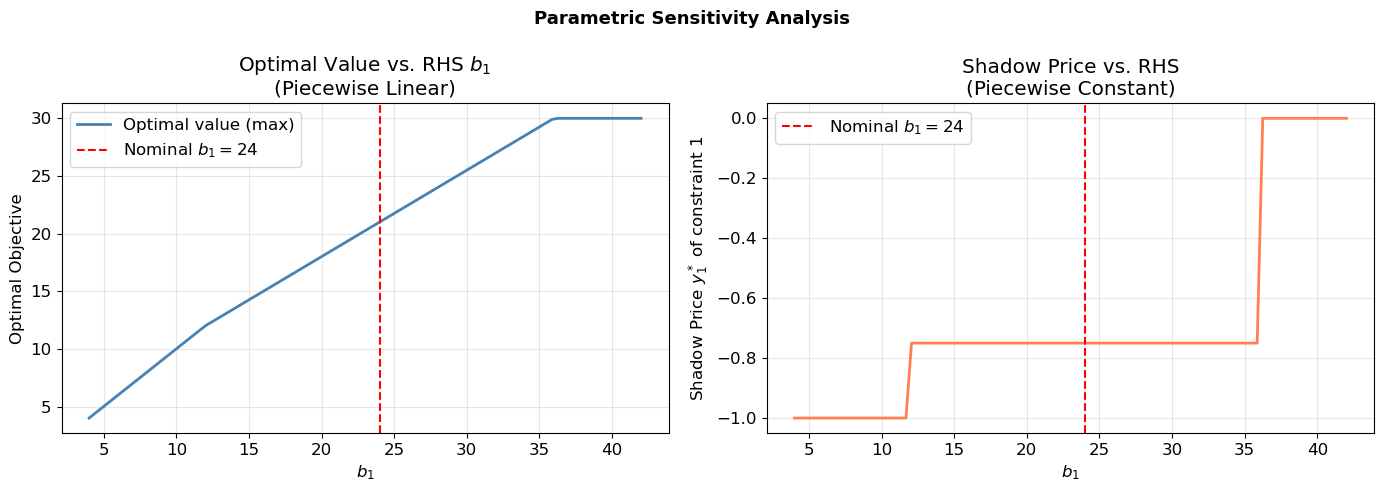

Shadow price at nominal (b1=24): -0.7500
Interpretation: each +1 unit of b1 changes max obj by 0.7500


In [15]:
# =============================================================================
# SECTION 7b: Parametric Analysis Visualization
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: optimal value vs. b1
b1_vals = np.linspace(4, 42, 100)
z_b1    = []
sp_b1   = []
for bv in b1_vals:
    r = linprog(c_min, A_ub=A_geom, b_ub=np.array([bv, 6.0]),
                bounds=[(0,None)]*2, method='highs')
    z_b1.append(-r.fun if r.success else np.nan)
    sp_b1.append(r.ineqlin.marginals[0] if r.success else np.nan)

ax = axes[0]
ax.plot(b1_vals, z_b1, color=COLOR_PRIMARY, linewidth=2, label='Optimal value (max)')
ax.axvline(24, color=COLOR_OPTIMAL, linestyle='--', linewidth=1.5, label='Nominal $b_1=24$')
ax.set_xlabel('$b_1$')
ax.set_ylabel('Optimal Objective')
ax.set_title('Optimal Value vs. RHS $b_1$\n(Piecewise Linear)')
ax.legend()

# Right: shadow price vs. b1 (piecewise constant = slope of left plot)
ax2 = axes[1]
ax2.plot(b1_vals, sp_b1, color=COLOR_SECONDARY, linewidth=2)
ax2.axvline(24, color=COLOR_OPTIMAL, linestyle='--', linewidth=1.5, label='Nominal $b_1=24$')
ax2.set_xlabel('$b_1$')
ax2.set_ylabel('Shadow Price $y_1^*$ of constraint 1')
ax2.set_title('Shadow Price vs. RHS\n(Piecewise Constant)')
ax2.legend()

plt.suptitle('Parametric Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

sp_nominal = sa['shadow_prices'][0]
print(f"Shadow price at nominal (b1=24): {sp_nominal:.4f}")
print(f"Interpretation: each +1 unit of b1 changes max obj by {abs(sp_nominal):.4f}")

---
## 8. Summary & References

### Method Comparison

| Method | Key Property | Handles Infeasibility | Duality Info | Complexity |
|--------|-------------|----------------------|--------------|------------|
| Geometric (2D) | Visual insight | No | No | $O(V)$ vertices |
| Simplex (Dantzig) | Most negative reduced cost | Needs feasible start | Yes | Exp. worst, poly avg |
| Simplex (Bland) | Anti-cycling guarantee | Needs feasible start | Yes | Finite, slower |
| Two-Phase Simplex | Phase I finds BFS | Yes | Yes | 2× simplex |
| Interior-Point | Follows central path | Yes | Yes | $O(n^{3.5})$ poly |

### Key Takeaways

$$
\boxed{
\text{Fundamental Theorem: If LP has an optimal solution, an optimal BFS exists}
\quad \Rightarrow \quad
\text{Simplex searches a finite set of vertices}
}
$$

1. **Standard form** unifies all LP variants via slack, surplus, and artificial variables.
2. **Simplex** is a vertex-walking algorithm: each step improves the objective by exchanging one basis variable.
3. **Dantzig's rule** (most negative reduced cost) is efficient in practice; **Bland's rule** prevents cycling.
4. **Strong duality** is LP's crown jewel — primal optimal always equals dual optimal when both exist.
5. **Shadow prices** are dual variables and quantify the marginal value of each constraint.
6. **Two-Phase Simplex** extends the method to arbitrary equality-constrained LPs.
7. **Sensitivity analysis** reveals how far problem data can change before the optimal basis shifts.

### References

1. Bertsimas, D., & Tsitsiklis, J. N. (1997). *Introduction to Linear Optimization*. Athena Scientific.
2. Dantzig, G. B. (1963). *Linear Programming and Extensions*. Princeton University Press.
3. Vanderbei, R. J. (2014). *Linear Programming: Foundations and Extensions* (4th ed.). Springer.
4. Bland, R. G. (1977). New finite pivoting rules for the simplex method. *Mathematics of Operations Research*, 2(2), 103–107.
5. Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. (Chapters 4–5 on LP duality.)
6. Nocedal, J., & Wright, S. J. (2006). *Numerical Optimization* (2nd ed.). Springer. (Chapter 13 on LP.)